In [131]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import mlflow
import mlflow.sklearn


In [132]:
df=pd.read_csv("india_housing_prices (1).csv")

In [133]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [134]:
df.drop('ID', axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 22 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   State                           250000 non-null  object 
 1   City                            250000 non-null  object 
 2   Locality                        250000 non-null  object 
 3   Property_Type                   250000 non-null  object 
 4   BHK                             250000 non-null  int64  
 5   Size_in_SqFt                    250000 non-null  int64  
 6   Price_in_Lakhs                  250000 non-null  float64
 7   Price_per_SqFt                  250000 non-null  float64
 8   Year_Built                      250000 non-null  int64  
 9   Furnished_Status                250000 non-null  object 
 10  Floor_No                        250000 non-null  int64  
 11  Total_Floors                    250000 non-null  int64  
 12  Age_of_Property 

In [11]:
df.columns

Index(['State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt',
       'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status',
       'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools',
       'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space',
       'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status'],
      dtype='object')

In [53]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


<AxesSubplot:xlabel='Price_in_Lakhs'>

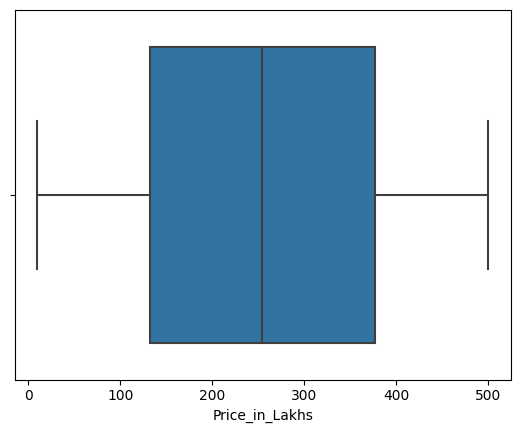

In [55]:
sns.boxplot(x=df["Price_in_Lakhs"])

In [56]:
df.skew(numeric_only=True)

BHK                 0.000543
Size_in_SqFt        0.000796
Price_in_Lakhs      0.008206
Price_per_SqFt      2.318668
Year_Built         -0.000167
Floor_No            0.005311
Total_Floors       -0.000666
Age_of_Property     0.000167
Nearby_Schools     -0.001258
Nearby_Hospitals    0.001099
dtype: float64

In [135]:
df["Price_per_SqFt"]=np.log1p(df["Price_per_SqFt"])

In [136]:
df["Price_per_SqFt"].skew()

1.8702861884400896

In [137]:
df.to_csv("india_housing_prices cleaned.csv",index=False)

EDA

Correlation univariate analysis

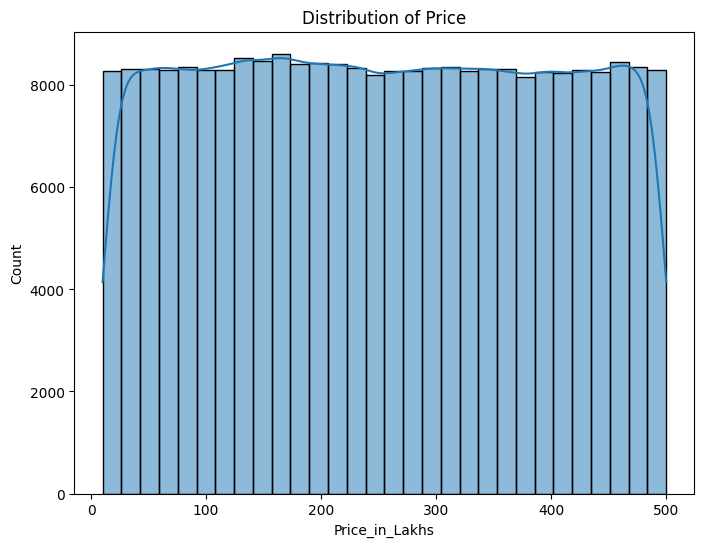

In [58]:


plt.figure(figsize=(8,6))
sns.histplot(df['Price_in_Lakhs'], bins=30, kde=True)
plt.title('Distribution of Price')
plt.show()

Bivariate analysis

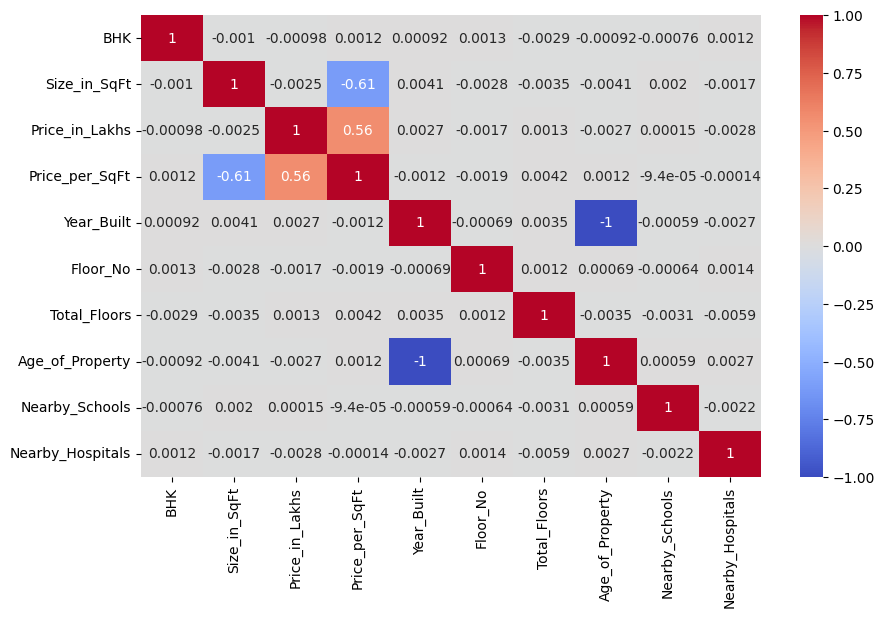

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

query

Price & Size Analysis

1.What is the distribution of property prices?


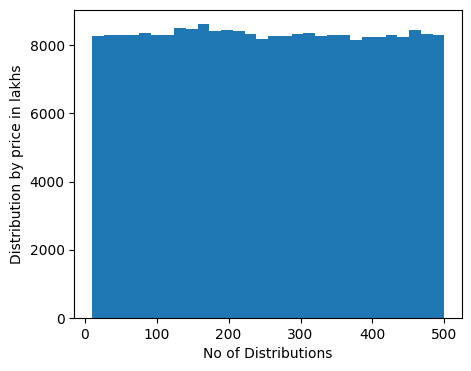

In [140]:
plt.figure(figsize=(5,4))
plt.hist(df["Price_in_Lakhs"],bins=30)
plt.xlabel("No of Distributions")
plt.ylabel("Distribution by price in lakhs")
plt.show()



2.What is the distribution of property sizes?


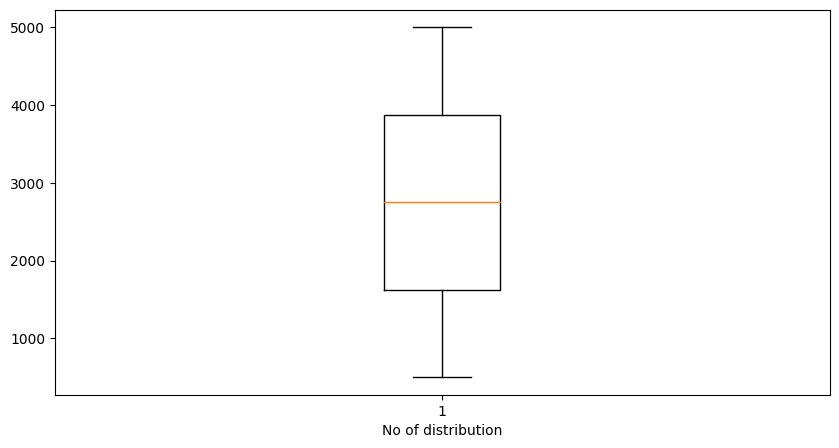

In [61]:
plt.figure(figsize=(10,5))
plt.boxplot(df["Size_in_SqFt"])
plt.xlabel("No of distribution")
plt.show()


In [7]:
df.head()

,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.095310,1990,Furnished,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.076961,2008,Unfurnished,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.048790,1997,Semi-furnished,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.104360,1991,Furnished,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.039221,2002,Semi-furnished,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


3.How does the price per sq ft vary by property type?

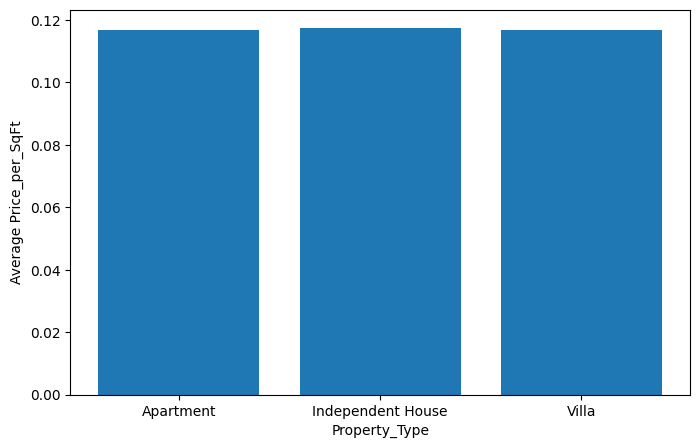

In [ ]:
variation=df.groupby('Property_Type')['Price_per_SqFt'].mean()
plt.figure(figsize=(8,5))
plt.bar(variation.index.astype(str),variation.values)
plt.xlabel('Property_Type')
plt.ylabel('Average Price_per_SqFt')
plt.show()

4.Is there a relationship between property type?

Text(0.5, 1.0, 'size vs price')

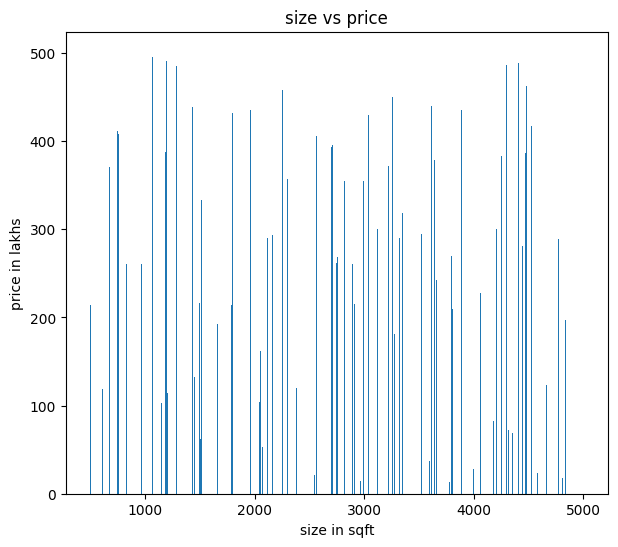

In [10]:

sample_df=df.sample(1000)
plt.figure(figsize=(7,6))
plt.bar(sample_df['Size_in_SqFt'],sample_df['Price_in_Lakhs'])
plt.xlabel('size in sqft')
plt.ylabel('price in lakhs')
plt.title('size vs price')

5.Are there any outliers in price per sq ft or property size?

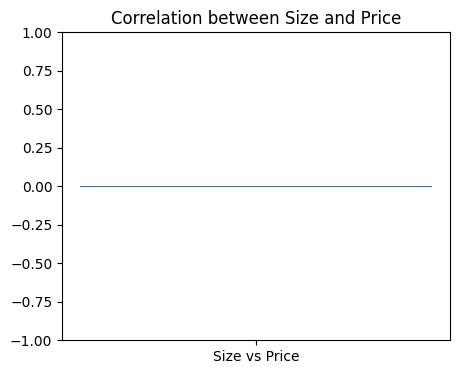

Correlation Value: -0.002528546792538916


In [16]:
corr_value = df['Size_in_SqFt'].corr(df['Price_in_Lakhs'])

plt.figure(figsize=(5,4))
plt.bar(['Size vs Price'], [corr_value])
plt.ylim(-1, 1)
plt.title("Correlation between Size and Price")
plt.show()

print("Correlation Value:", corr_value)

Location based analysis
6.What is the average Price per sq ft by state?

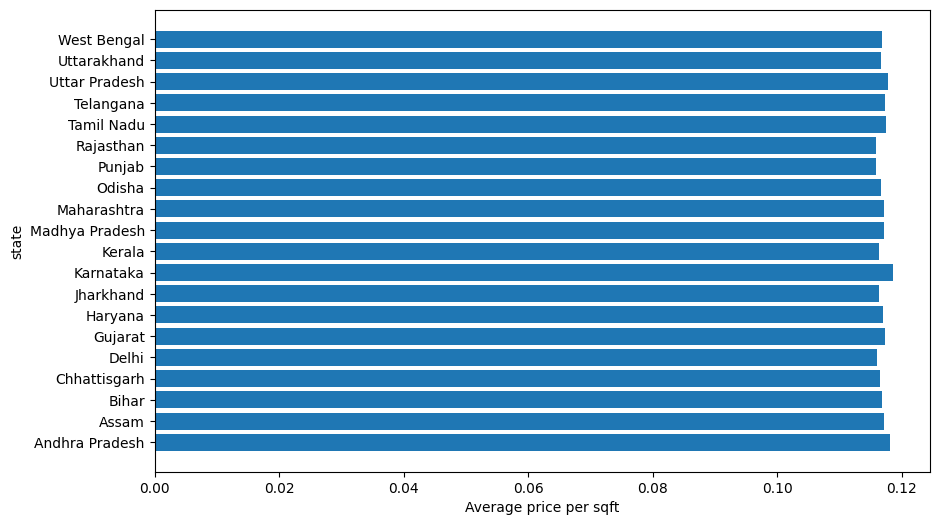

In [ ]:
average =df.groupby('State')['Price_per_SqFt'].mean()
plt.figure(figsize=(10,6))
plt.barh(average.index.astype(str),average.values)
plt.xlabel('Average price per sqft')
plt.ylabel('state')
plt.show()

7.What is the average property price by city?

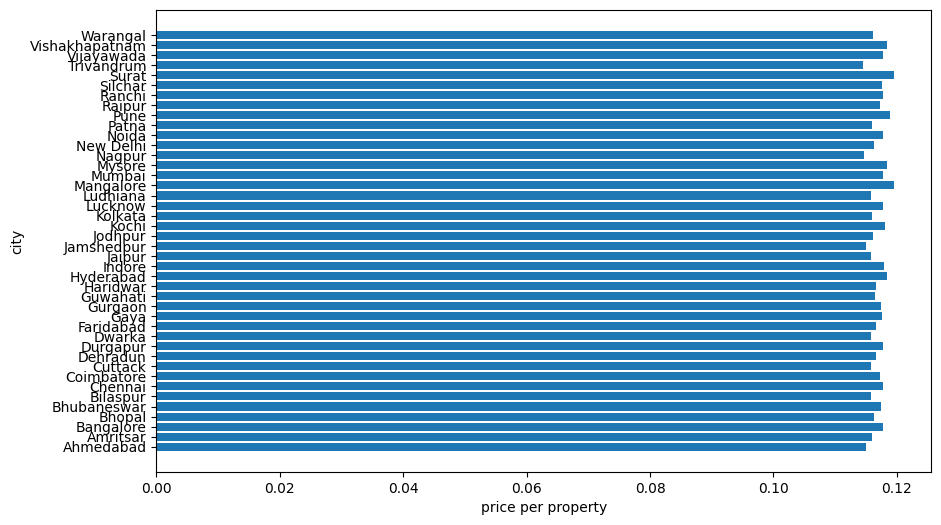

In [35]:
average=df.groupby('City')['Price_per_SqFt'].mean()
plt.figure(figsize=(10,6))
plt.barh(average.index.astype(str),average.values)
plt.xlabel('price per property')
plt.ylabel('city')
plt.show()

8.What is the median age of properties by locality?

<Figure size 1000x600 with 0 Axes>

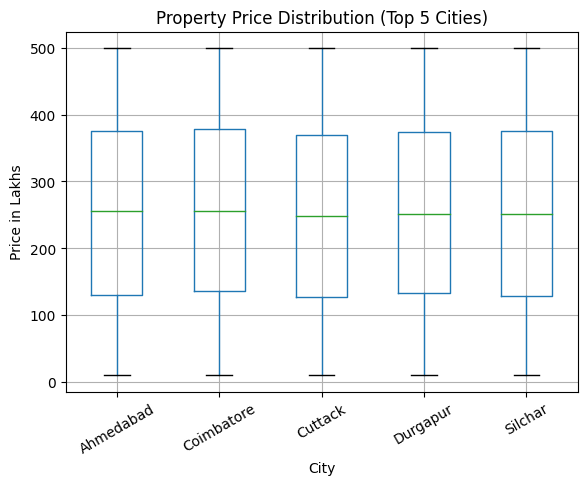

In [41]:

top_cities = df["City"].value_counts().head(5).index
filtered_df = df[df["City"].isin(top_cities)]

plt.figure(figsize=(10,6))

filtered_df.boxplot(column="Price_in_Lakhs", by="City")

plt.xticks(rotation=30)
plt.title("Property Price Distribution (Top 5 Cities)")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("Price in Lakhs")

plt.show()

9.How is BHK distributed across cities?

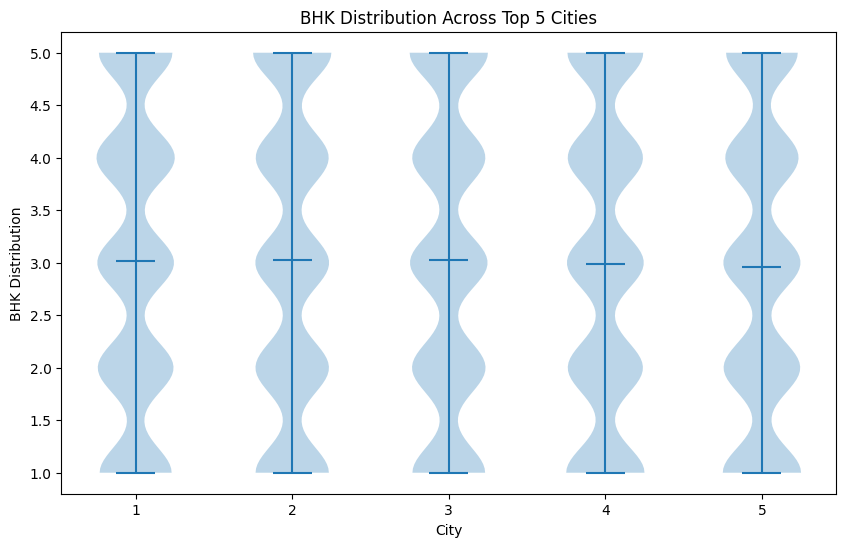

In [42]:

top_cities = df["City"].value_counts().head(5).index
filtered_df = df[df["City"].isin(top_cities)]

plt.figure(figsize=(10,6))

data = [filtered_df[filtered_df["City"] == city]["BHK"] for city in top_cities]
plt.violinplot(data, showmeans=True)
plt.xlabel("City")
plt.ylabel("BHK Distribution")
plt.title("BHK Distribution Across Top 5 Cities")

plt.show()

10.What are the price trends for the top 5 most expensive locality?

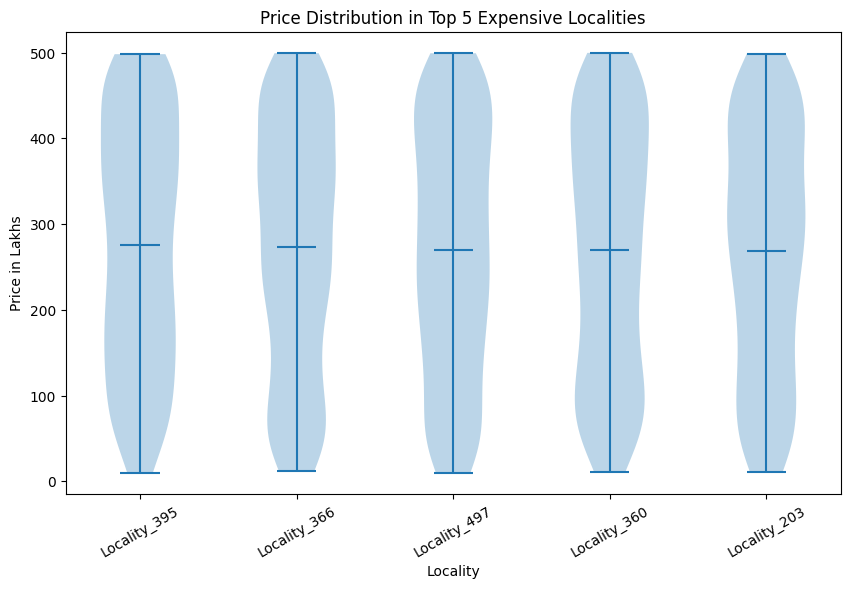

In [ ]:
top_localities = (
    df.groupby("Locality")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered_df = df[df["Locality"].isin(top_localities)]

plt.figure(figsize=(10,6))

data = [filtered_df[filtered_df["Locality"] == loc]["Price_in_Lakhs"] for loc in top_localities]

plt.violinplot(data, showmeans=True)

plt.xticks(range(1, len(top_localities)+1), top_localities, rotation=30)
plt.xlabel("Locality")
plt.ylabel("Price in Lakhs")
plt.title("Price Distribution in Top 5 Expensive Localities")

plt.show()

Feature relationship and correlation
11.How are numeric features correlated with each other?

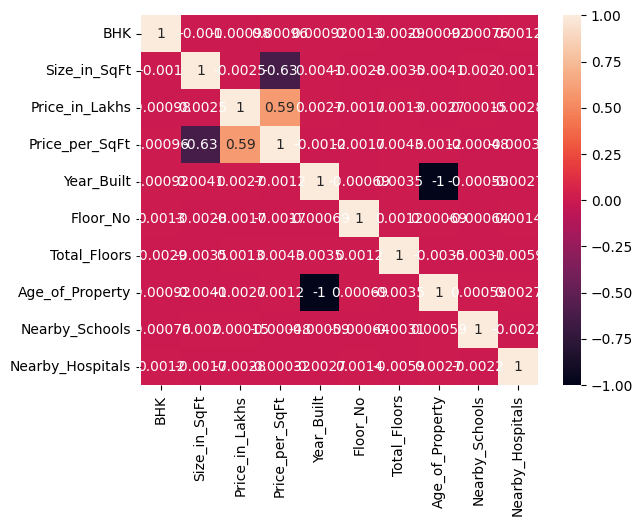

In [98]:
numeric=df.select_dtypes(include=['int64','float64'])
corr=numeric.corr()
sns.heatmap(corr,annot=True)
plt.show()



12.How do nearby schools relate to price per sq ft?


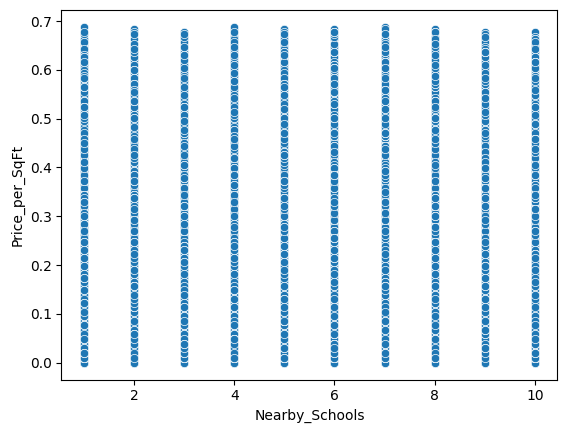

In [100]:

sns.scatterplot(x='Nearby_Schools',y='Price_per_SqFt',data=df)
plt.show()

13.How do nearby hospitals relate to price per sq ft?


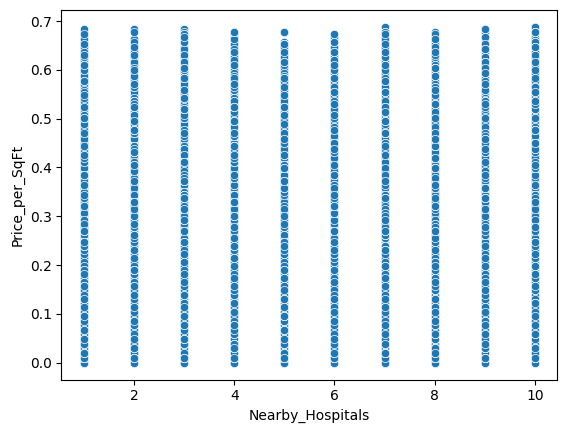

In [101]:
sns.scatterplot(x='Nearby_Hospitals',y='Price_per_SqFt',data=df)
plt.show()

14.How does price vary by furnished status?


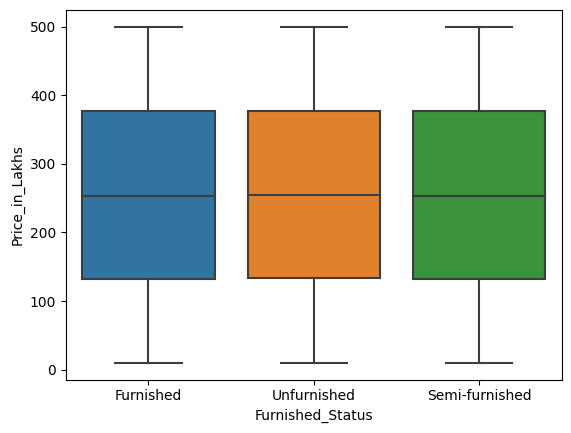

In [102]:
sns.boxplot(x='Furnished_Status',y='Price_in_Lakhs',data=df)
plt.show()

15.How does price per sq ft vary by property facing direction?


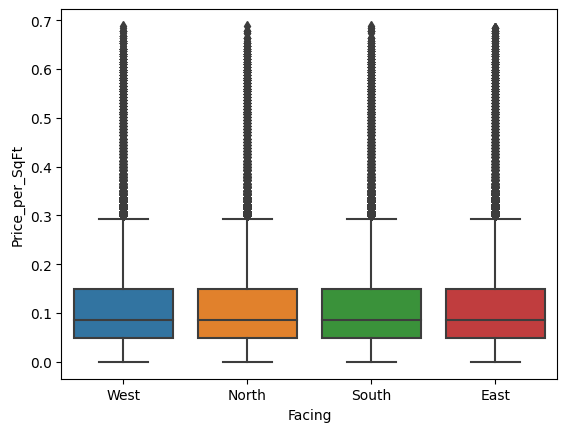

In [105]:
sns.boxplot(x='Facing',y='Price_per_SqFt',data=df)
plt.show()

 Investment / Amenities / Ownership Analysis
16.How many properties belong to each owner type?




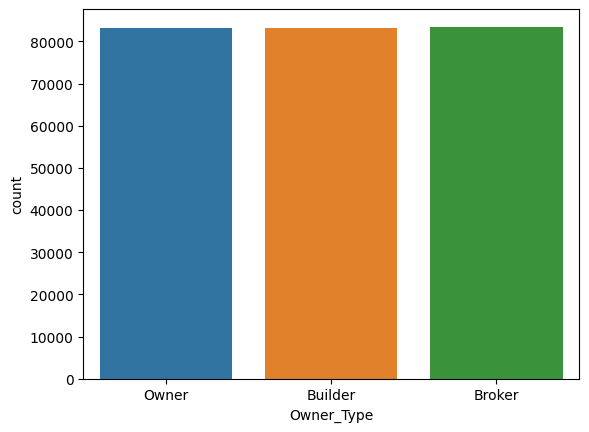

In [113]:

sns.countplot(x='Owner_Type',data=df)
plt.show()

17.How many properties are available under each availability status?


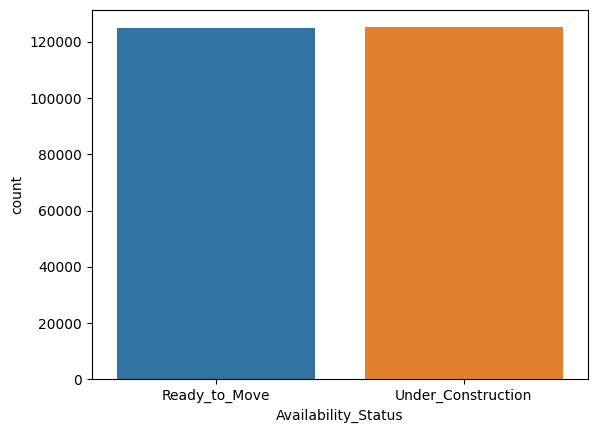

In [ ]:
sns.countplot(x='Availability_Status',data=df)
plt.show()

18.Does parking space affect property price?

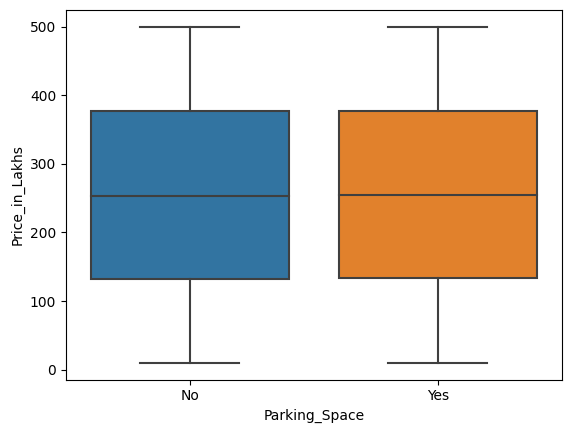

In [118]:
sns.boxplot(x='Parking_Space',y='Price_in_Lakhs',data=df)
plt.show()

19.How do amenities affect price per sq ft?

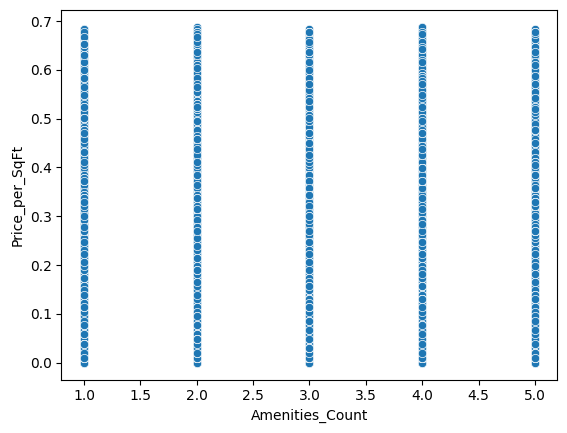

In [123]:
df['Amenities_Count'] = df['Amenities'].apply(lambda x: len(str(x).split(',')))
sns.scatterplot(x='Amenities_Count',y='Price_per_SqFt',data=df)
plt.show()

20.How does public transport accessibility relate to price per sq ft or investment potential?




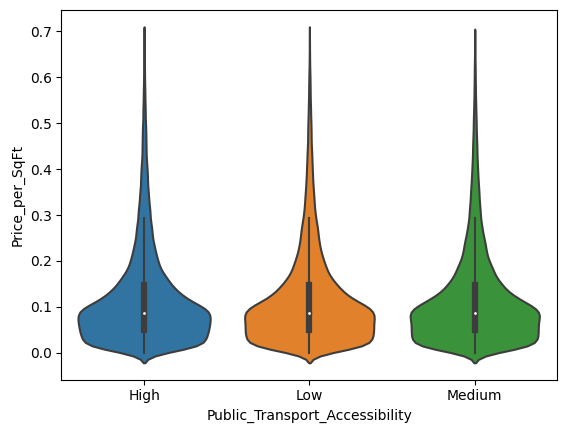

In [130]:
sns.violinplot(x='Public_Transport_Accessibility',y='Price_per_SqFt',data=df)
plt.show()

regression model

In [44]:
r = 0.08
t = 5

df['Future_Price'] = df['Price_in_Lakhs'] * ((1 + r) ** t)

classification model

In [45]:
median_price = df['Price_in_Lakhs'].median()

df['Good_Investment'] = df['Price_in_Lakhs'].apply(
    lambda x: 1 if x <= median_price else 0
)

In [46]:
df = pd.get_dummies(df, drop_first=True)

X and targets

For classification

In [47]:
X_reg = df.drop(['Price_in_Lakhs','Future_Price','Good_Investment'], axis=1)
y_reg = df['Future_Price']

classification

In [48]:
X_clf = df.drop(['Price_in_Lakhs','Future_Price','Good_Investment'], axis=1)
y_clf = df['Good_Investment']

step4:Train test split

In [49]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

step5:Feature scaling 

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

step:6 Model Building

Regression Model

Random forest regressor

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=50,      # reduce trees
    max_depth=15, 
    min_samples_split=10,
    n_jobs =1,      # limit tree depth
    random_state=42
)

rf_reg.fit(X_train_reg, y_train_reg)

y_pred_rf = rf_reg.predict(X_test_reg)

In [53]:
rf_reg.fit(X_train_reg, y_train_reg)

RandomForestRegressor(max_depth=15, min_samples_split=10, n_estimators=50,
                      n_jobs=-1, random_state=42)

In [54]:
y_pred_rf=rf_reg.predict(X_test_reg)
y_pred_rf

array([377.55301925, 137.0662482 , 363.77561725, ...,  81.76286594,
       435.24931152, 201.27841984])

In [55]:
y_reg

0         719.618119
1         287.283026
2         270.047807
3         441.224528
4         268.740105
             ...    
249995    403.697889
249996     19.688996
249997    348.142595
249998    208.145015
249999    293.410124
Name: Future_Price, Length: 250000, dtype: float64

evaluation for rf

In [71]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)))
print("R2:", r2_score(y_test_reg, y_pred_rf))

MAE: 10.116370420724394
RMSE: 12.963294423244388
R2: 0.9960954951951456


Linear Regression

In [65]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_reg)

In [66]:
y_pred_lin=lin_reg.predict(X_test_reg)
y_pred_lin

array([546.52069325, 246.8213014 , 469.77729935, ..., 205.73969785,
       369.64912924, 376.57986507])

evaluation for lin

In [72]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test_reg, y_pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_lin)))
print("R2:", r2_score(y_test_reg, y_pred_lin))

MAE: 107.55180436748888
RMSE: 136.07298288185035
R2: 0.569791484856307


XGboost regression

In [67]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor()
xgb_reg.fit(X_train_reg, y_train_reg)
y_pred_xgb=xgb_reg.predict(X_test_reg)


In [69]:
y_pred_xgb=xgb_reg.predict(X_test_reg)
y_pred_xgb

array([368.7814 , 135.4859 , 366.3038 , ...,  81.3898 , 430.96118,
       204.63649], dtype=float32)

Evaluation for xgb

In [70]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test_reg, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb)))
print("R2:", r2_score(y_test_reg, y_pred_xgb))

MAE: 10.734440733808356
RMSE: 13.515222992799448
R2: 0.9957559389429986


##Best model is rf

In [74]:
import joblib

joblib.dump(rf_reg, "rf_future_price_model.pkl")

['rf_future_price_model.pkl']

Classification Model

Random forest classifier

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
mlflow.set_tracking_uri("http://127.0.0.1:5000")
X = X_clf
y = y_clf

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)



Accuracy: 0.81


In [81]:
y_pred = rf.predict(X_test)
y_pred 


array([0, 1, 1, ..., 1, 0, 1], dtype=int64)

Evaluation for rf in classification

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test_clf, y_pred))
print("Precision:", precision_score(y_test_clf, y_pred))
print("Recall:", recall_score(y_test_clf, y_pred))
print("ROC AUC:", roc_auc_score(y_test_clf, y_pred))

Accuracy: 0.81
Precision: 0.9510149788907524
Recall: 0.6552177551101726
ROC AUC: 0.8106028943402125


Logistics Regression

In [78]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression()
log_clf.fit(X_train_clf, y_train_clf)
y_pred_log = log_clf.predict(X_test)

c:\Users\DELL XPS\OneDrive\Desktop\AIML\AIML\env\lib\site-packages\sklearn\linear_model\_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


In [80]:
y_pred_log = log_clf.predict(X_test)
y_pred_log 


array([0, 1, 0, ..., 1, 1, 0], dtype=int64)

In [83]:
print("Accuracy:", accuracy_score(y_test_clf, y_pred_log))
print("Precision:", precision_score(y_test_clf, y_pred_log))
print("Recall:", recall_score(y_test_clf, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test_clf, y_pred_log))

Accuracy: 0.69744
Precision: 0.6976799524092802
Recall: 0.700960274136351
ROC AUC: 0.6974262881343121


XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier()
xgb_clf.fit(X_train_clf, y_train_clf)
y_pred_xgb = xgb_clf.predict(X_test)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [79]:
y_pred_xgb = xgb_clf.predict(X_test)
y_pred_xgb 


array([0, 1, 1, ..., 1, 0, 1])

In [1]:
print("Accuracy:", accuracy_score(y_test_clf, y_pred_xgb))
print("Precision:", precision_score(y_test_clf, y_pred_xgb))
print("Recall:", recall_score(y_test_clf, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test_clf, y_pred_xgb))

NameError: name 'accuracy_score' is not defined

In [148]:
joblib.dump(xgb_clf, "xgb_classification_model.pkl")

['xgb_classification_model.pkl']

In [34]:
print('Price_in_Lakhs'in X_clf.columns)

False


In [35]:
X=df.drop("Price_in_Lakhs",axis=1)

evaluation

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[24056   847]
 [ 8653 16444]]
              precision    recall  f1-score   support

           0       0.74      0.97      0.84     24903
           1       0.95      0.66      0.78     25097

    accuracy                           0.81     50000
   macro avg       0.84      0.81      0.81     50000
weighted avg       0.84      0.81      0.81     50000



In [153]:
model=joblib.load("model_columns.pkl")
print(type(model))

<class 'pandas.core.indexes.base.Index'>


In [152]:
joblib.dump(X.columns,"model_columns.pkl")

['model_columns.pkl']

In [150]:
joblib.dump(X.columns,"rf_future_price_model_pipeline.pkl")

['rf_future_price_model_pipeline.pkl']